<a href="https://colab.research.google.com/github/hamshini1413/NLP/blob/main/NLP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
from nltk.corpus import stopwords

print("Libraries Imported Successfully")

Libraries Imported Successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [3]:
df = pd.read_csv("IMDB Dataset.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
review       0
sentiment    0
dtype: int64


In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    text = " ".join(word for word in text.split() if word not in stop_words)

    return text

df['clean_review'] = df['review'].apply(clean_text)

print(df[['review','clean_review']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


In [6]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])

y = df['sentiment']

print(X.shape)

(50000, 5000)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [9]:
predictions = model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 0.8873


In [11]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



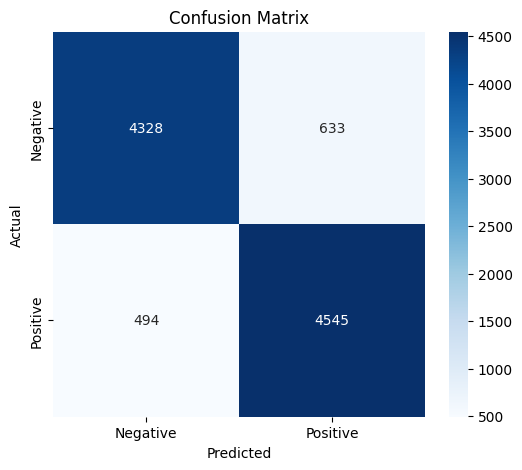

In [12]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
print(df['sentiment'].value_counts())


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


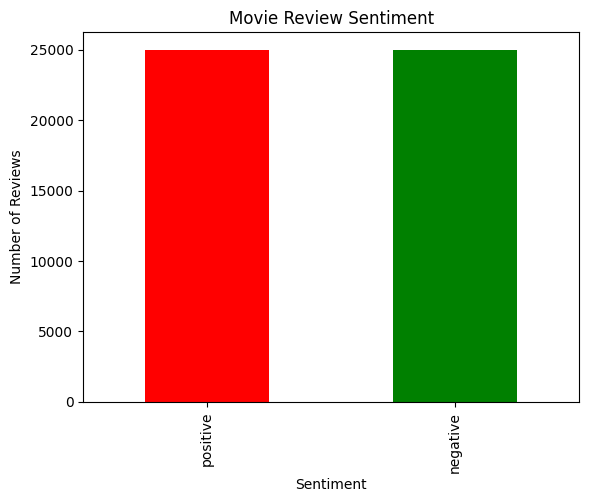

In [14]:
df['sentiment'].value_counts().plot(
    kind='bar',
    color=['red','green']
)

plt.title("Movie Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

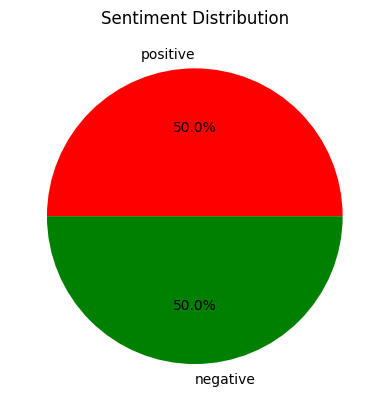

In [15]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['red','green']
)

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [16]:
review = ["The movie was absolutely amazing with great acting"]

review = [clean_text(review[0])]

vector = vectorizer.transform(review)

prediction = model.predict(vector)

print("Prediction:", prediction[0])

Prediction: positive


In [17]:
review = ["Worst movie ever. Waste of time. Terrible acting."]

review = [clean_text(review[0])]

vector = vectorizer.transform(review)

prediction = model.predict(vector)

print("Prediction:", prediction[0])

Prediction: negative


In [18]:
user_review = input("Enter a movie review: ")

clean = clean_text(user_review)

vector = vectorizer.transform([clean])

prediction = model.predict(vector)

print("\nPredicted Sentiment:", prediction[0])

Enter a movie review: 5

Predicted Sentiment: negative
